In [ ]:
# THỰC HÀNH 5: XÁC ĐỊNH ĐỐI TƯỢNG TRONG ẢNH

## 1. Cài đặt thư viện

In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Viết chương trình gán nhãn ảnh

### 2.1 Gán nhãn ảnh

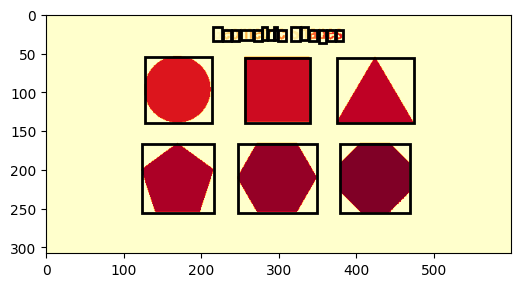

In [ ]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu
data = Image.open('geometric.png').convert('L')
a = np.asarray(data)
thres = threshold_otsu(a)
b = a > thres 
c = label(b)
c_uint8 = (c % 256).astype(np.uint8)
iio.imwrite('label_output.jpg', c_uint8)
properties = ['Area', 'Centroid', 'BoundingBox']
d = regionprops(c)
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 6))
ax.imshow(c, cmap='YlOrRd')
for i in d:
    lr, lc, ur, uc = i['BoundingBox']
    rec_width = uc - lc
    rec_height = ur - lr
    rect = mpatches.Rectangle((lc, lr), rec_width, rec_height, fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(rect)

plt.show()


### 2.2 Dò tìm cạnh theo chiều dọc

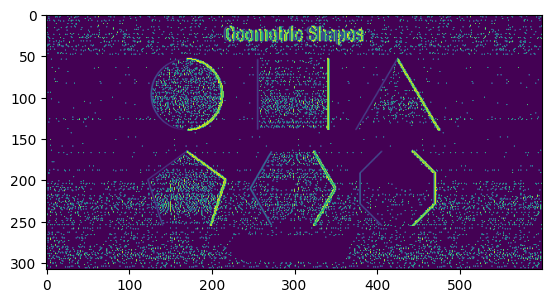

In [8]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

data = Image.open('geometric.png').convert('L')
bmg = abs(data - nd.shift(data, (0, 1), order=0))
plt.imshow(bmg)
plt.show()


### 2.3 Dò tìm cạnh Sobel Filter

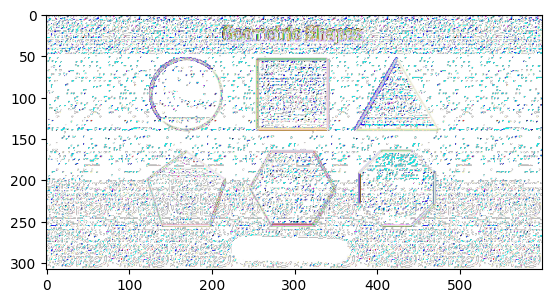

In [9]:
from PIL import Image
import numpy as np
import cv2
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pylab as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

data = Image.open('geometric.png')
a = nd.sobel(data, axis=0)
b = nd.sobel(data, axis=1)
bmg = abs(a) + abs(b)
plt.imshow(bmg)
plt.show()


### 2.4 Xác định góc của đối tượng

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-49.800000000000004..255.0].


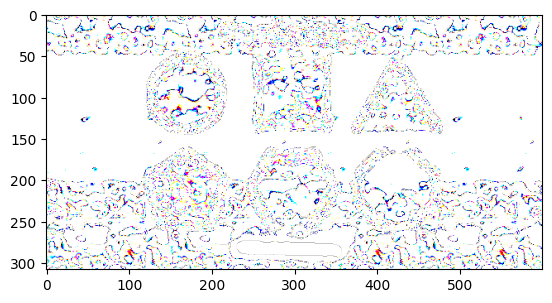

In [3]:
from PIL import Image
import numpy as np
import cv2
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

def Harris(indata, alpha=0.2):
    x = nd.sobel(indata, 0)
    y = nd.sobel(indata, 1)
    x1 = x ** 2
    y1 = y ** 2
    xy = abs(x * y)
    x1 = nd.gaussian_filter(x1,3)
    y1 = nd.gaussian_filter(y1,3)
    xy = nd.gaussian_filter(xy,3)

    detC = x1 * y1 - 2 * xy
    trC = x1 + y1
    R = detC - alpha * trC**2
    return R

data = Image.open('geometric.png')
bmg = Harris(data)
plt.imshow(bmg)
plt.show()

### 2.5 Dò tìm hình dạng cụ thể trong ảnh với Hough Transform

#### 2.5.1 Dò tìm ảnh thẳng trong ảnh

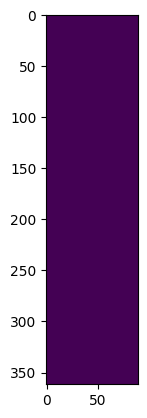

In [11]:
import numpy as np
import cv2
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu


def LineHough(data, gamma):
    V, H = data.shape
    R = int(np.sqrt(V * V + H * H))
    ho = np.zeros((R, 90), float) #Hough space
    w = data + 0
    ok = 1

    theta = np.arange(90)/180 * np.pi
    tp = np.arange(90).astype(float)

    while ok:
        mx = w.max()
        if mx < gamma:
            ok = 0
        else:
            v, h = divmod(w.argmax(), H)
            y = v - V
            x = h - H
            rh = x * np.cos(theta) + y * np.sin(theta)
            for i in range(len(rh)):
                if 0 <= rh[i] < R and 0 <= tp[i] < 90:
                    ho[int(rh[i]), int(tp[i])] += mx
            w[v,h] = 0
    return ho


data = np.zeros((256, 256))
data[128, 128] = 1
bmg = LineHough(data, 0.5)
plt.imshow(bmg)
plt.show()

#### 2.5.2 Dò tìm đường tròn trong ảnh

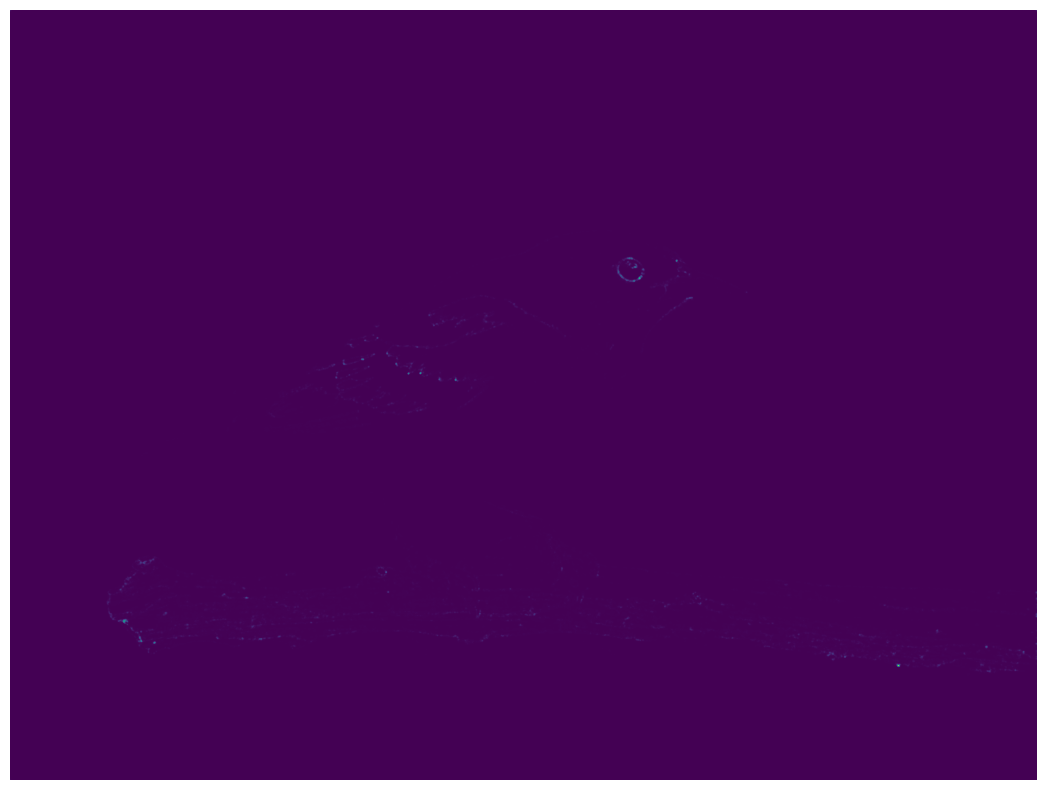

In [12]:
from PIL import Image
import numpy as np
import cv2
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.feature import corner_harris
from skimage.color import rgb2gray

data = iio.imread('bird.png')
image_gray = rgb2gray(data)
coordinate = corner_harris(image_gray, k = 0.001)

plt.figure(figsize=(20,10))
plt.imshow(coordinate)
plt.axis('off')
plt.show()

### 2.6 Image matching

Harris: 2074 keypoints ở ảnh 1, 14924 keypoints ở ảnh 2
SIFT descriptor: (2074, 128) (14924, 128)
Tổng số matches: 221
Số inliers sau RANSAC: 25


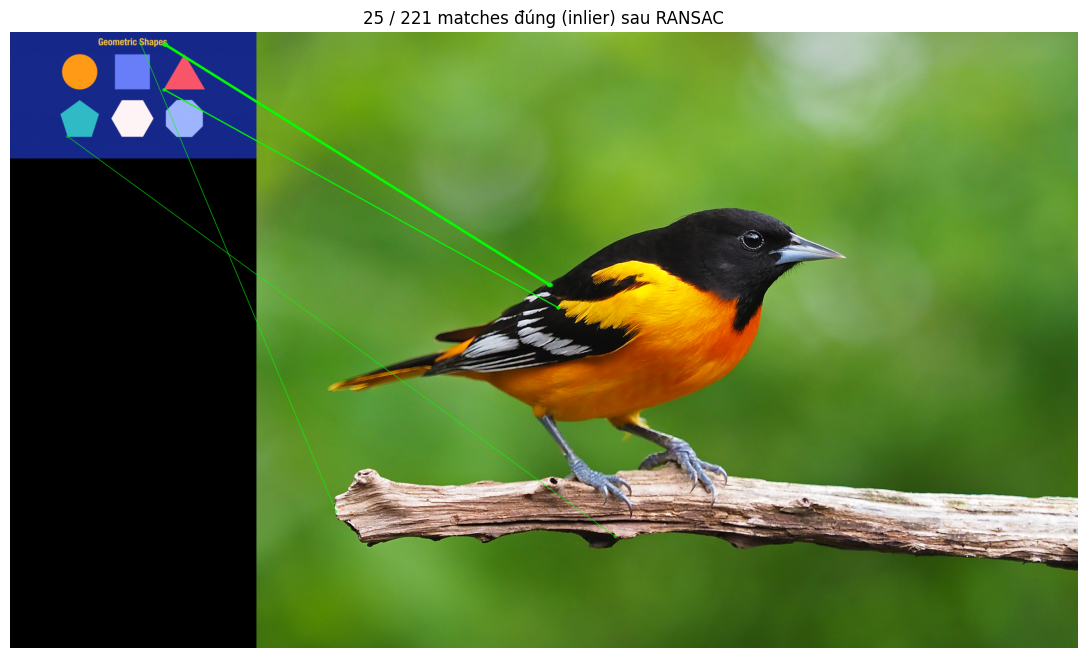

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img1 = cv2.imread('geometric.png')          
img2 = cv2.imread('bird.png')         
assert img1 is not None and img2 is not None, "Không tìm được file ảnh!"

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

def harris_keypoints(gray, k=0.04, thresh=0.01):
    harris = cv2.cornerHarris(np.float32(gray), blockSize=2, ksize=3, k=k)
    harris = cv2.dilate(harris, None)
    keypoints = np.argwhere(harris > thresh * harris.max())
    return [cv2.KeyPoint(float(x), float(y), 3) for y, x in keypoints]

kp1 = harris_keypoints(gray1)
kp2 = harris_keypoints(gray2)
print(f'Harris: {len(kp1)} keypoints ở ảnh 1, {len(kp2)} keypoints ở ảnh 2')

sift = cv2.SIFT_create()
kp1, des1 = sift.compute(gray1, kp1)
kp2, des2 = sift.compute(gray2, kp2)
print("SIFT descriptor:", des1.shape, des2.shape)

bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True) 
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda m: m.distance)

src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
matchesMask = mask.ravel().tolist()

print(f'Tổng số matches: {len(matches)}')
print(f'Số inliers sau RANSAC: {np.sum(matchesMask)}')

draw_params = dict(
    matchesMask=matchesMask,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    matchColor=(0,255,0),
    singlePointColor=(0,0,255)
)

vis = cv2.drawMatches(img1, kp1, img2, kp2, matches, None, **draw_params)

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f"{np.sum(matchesMask)} / {len(matches)} matches đúng (inlier) sau RANSAC")
plt.axis('off')
plt.show()